In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import sys
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Import minor locator ticker
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from re import split
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import skew
import matplotlib.image as mpimg

from scipy import stats
from scipy.stats import norm, gamma, logistic, t, lognorm, expon, betaprime
# from scipy.special import gamma

from scipy.optimize import curve_fit

import calendar

# from dask_jobqueue import SLURMCluster

# from dask.distributed import Client, progress
from IPython.display import Image
from dask.distributed import Client
import folium

import warnings

warnings.filterwarnings('ignore')

import seaborn as sns
# import hvplot.xarray

import Functions as Func

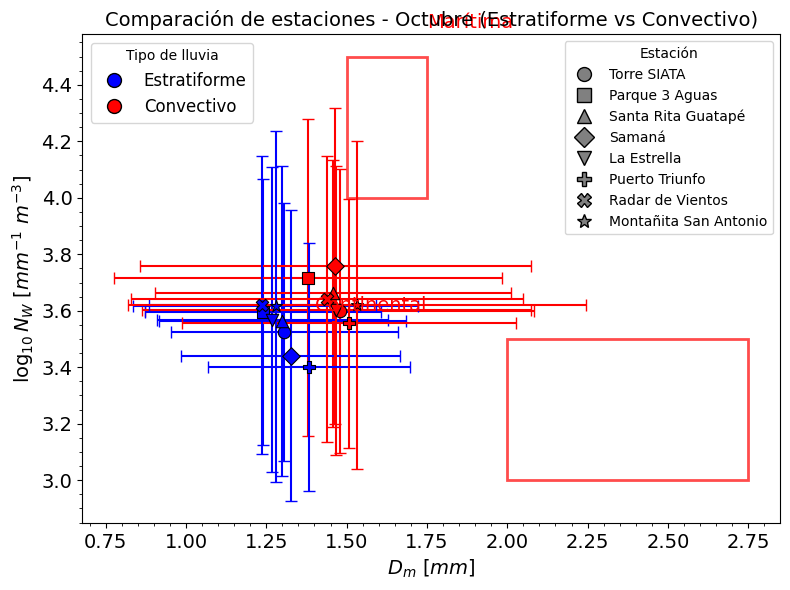

In [ ]:
# =========================================================
# 📊 Configuración
# =========================================================

month = 10  # Mes a graficar (1 = Enero)
std_threshold = 2  # Umbral STD(r_int_filt) estratiforme/convectivo

stations = {
    "Torre SIATA": "77_filtrado_plot.zarr",
    "Parque 3 Aguas": "78_filtrado_plot.zarr",
    "Santa Rita Guatapé": "139_filtrado_plot.zarr",
    "Samaná": "159_filtrado_plot.zarr",
    "La Estrella": "231_filtrado_plot.zarr",
    "Puerto Triunfo": "257_filtrado_plot.zarr",
    "Radar de Vientos": "351_filtrado_plot.zarr",
    "Montañita San Antonio": "425_filtrado_plot.zarr"
}

# Marcadores distintos por estación (8 estaciones -> 8 símbolos)
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

# =========================================================
# 🕸️ Crear figura
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

for (station_name, zarr_file), marker in zip(stations.items(), markers):

    ds = xr.open_zarr(
        DATA_PATH / "resultados" / "Zarr" / zarr_file
    )

    # Filter
    ds = ds.dropna(dim="time", subset=["lwc_filt"])

    # Seleccionar el mes deseado
    ds_month = ds.where(ds.time.dt.month == month, drop=True)

    # =====================================================
    # 🔄 Clasificar por tipo de lluvia usando STD(r_int_filt)
    # Se calcula STD por evento/ventana temporal usando
    # un resample diario; cada día se clasifica según su
    # STD(r_int_filt)
    # =====================================================

    r_series = ds_month.r_int_filt.to_series()

    daily_std = r_series.resample('D').std()

    strat_days = daily_std[daily_std < std_threshold].index
    conv_days = daily_std[daily_std >= std_threshold].index

    # =====================================================
    # 📊 Calcular promedio y STD de Dm y log10(Nw) para cada tipo
    # =====================================================

    dm_series = ds_month.d_m_filt.to_series()
    nw_series = np.log10(ds_month.n_w_filt.to_series())

    for days, color, label_suffix in [
        (strat_days, 'blue', 'Estratiforme'),
        (conv_days, 'red', 'Convectivo')
    ]:

        if len(days) == 0:
            continue

        mask = dm_series.index.normalize().isin(days)

        dm_subset = dm_series[mask]
        nw_subset = nw_series[mask]

        if dm_subset.empty:
            continue

        mean_dm = dm_subset.mean()
        mean_nw = nw_subset.mean()
        std_dm = dm_subset.std()
        std_nw = nw_subset.std()

        # Punto medio
        ax.scatter(
            mean_dm,
            mean_nw,
            color=color,
            marker=marker,
            s=80,
            edgecolors='black',
            linewidths=0.8,
            zorder=3,
            label=f"{station_name} - {label_suffix}"
        )

        # Cruz de desviación estándar
        ax.errorbar(
            mean_dm,
            mean_nw,
            xerr=std_dm,
            yerr=std_nw,
            fmt='none',
            ecolor=color,
            elinewidth=1.5,
            capsize=4,
            zorder=2
        )

# =========================================================
# 📦 Cajas de referencia
# =========================================================

rect1 = patches.Rectangle(
    (1.5, 4), width=0.25, height=0.5,
    linewidth=2, edgecolor='red', facecolor='none', alpha=0.7
)
rect2 = patches.Rectangle(
    (2, 3), width=0.75, height=0.5,
    linewidth=2, edgecolor='red', facecolor='none', alpha=0.7
)
ax.add_patch(rect1)
ax.add_patch(rect2)

plt.text(1.4, 3.6, 'Continental', fontsize=14, color='red')
plt.text(1.75, 4.6, 'Marítima', fontsize=14, color='red')

# =========================================================
# 🏷️ Etiquetas
# =========================================================

ax.set_xlabel('$D_m\\ [mm]$', fontsize=14)
ax.set_ylabel('$\\log_{10}N_W\\ [mm^{-1}\\ m^{-3}]$', fontsize=14)
ax.set_title(
    f'Comparación de estaciones - {month_names[month]} '
    f'(Estratiforme vs Convectivo)',
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# ax.set_xlim(0, 8)
# ax.set_ylim(0, 6)

# =========================================================
# 🏷️ Leyenda personalizada
# =========================================================

# Leyenda de colores (tipo de lluvia)
from matplotlib.lines import Line2D

color_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='Estratiforme'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='black', markersize=10, label='Convectivo'),
]

# Leyenda de marcadores (estación)
station_legend = [
    Line2D([0], [0], marker=m, color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=10, label=name)
    for (name, _), m in zip(stations.items(), markers)
]

legend1 = ax.legend(handles=color_legend, loc='upper left',
                     fontsize=12, title="Tipo de lluvia")
ax.add_artist(legend1)

ax.legend(handles=station_legend, loc='upper right',
          fontsize=10, title="Estación")

plt.tight_layout()

# plt.savefig(
#     instrument_path / f"Comparacion_Dm_Nw_{month_names[month]}_Estrat_Conv.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

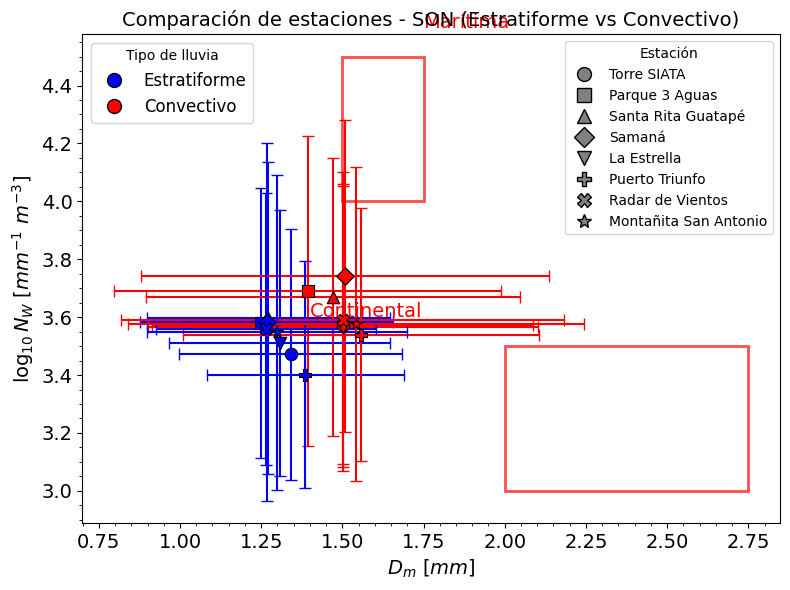

In [72]:
# =========================================================
# 📊 OPCIÓN 1: Separar por estaciones del año (DJF, MAM, JJA, SON)
# =========================================================

season = "SON"  # Opciones: "DJF", "MAM", "JJA", "SON"
std_threshold = 2

stations = {
    "Torre SIATA": "77_filtrado_plot.zarr",
    "Parque 3 Aguas": "78_filtrado_plot.zarr",
    "Santa Rita Guatapé": "139_filtrado_plot.zarr",
    "Samaná": "159_filtrado_plot.zarr",
    "La Estrella": "231_filtrado_plot.zarr",
    "Puerto Triunfo": "257_filtrado_plot.zarr",
    "Radar de Vientos": "351_filtrado_plot.zarr",
    "Montañita San Antonio": "425_filtrado_plot.zarr"
}

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

season_months = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

fig, ax = plt.subplots(figsize=(8, 6))

for (station_name, zarr_file), marker in zip(stations.items(), markers):

    ds = xr.open_zarr(DATA_PATH / "resultados" / "Zarr" / zarr_file)
    ds = ds.dropna(dim="time", subset=["lwc_filt"])

    # Seleccionar la temporada deseada
    ds_season = ds.where(ds.time.dt.month.isin(season_months[season]), drop=True)

    r_series = ds_season.r_int_filt.to_series()
    daily_std = r_series.resample('D').std()

    strat_days = daily_std[daily_std < std_threshold].index
    conv_days = daily_std[daily_std >= std_threshold].index

    dm_series = ds_season.d_m_filt.to_series()
    nw_series = np.log10(ds_season.n_w_filt.to_series())

    for days, color, label_suffix in [
        (strat_days, 'blue', 'Estratiforme'),
        (conv_days, 'red', 'Convectivo')
    ]:

        if len(days) == 0:
            continue

        mask = dm_series.index.normalize().isin(days)

        dm_subset = dm_series[mask]
        nw_subset = nw_series[mask]

        if dm_subset.empty:
            continue

        mean_dm = dm_subset.mean()
        mean_nw = nw_subset.mean()
        std_dm = dm_subset.std()
        std_nw = nw_subset.std()

        ax.scatter(
            mean_dm, mean_nw,
            color=color, marker=marker, s=80,
            edgecolors='black', linewidths=0.8, zorder=3,
            label=f"{station_name} - {label_suffix}"
        )

        ax.errorbar(
            mean_dm, mean_nw,
            xerr=std_dm, yerr=std_nw,
            fmt='none', ecolor=color, elinewidth=1.5, capsize=4, zorder=2
        )

rect1 = patches.Rectangle((1.5, 4), width=0.25, height=0.5, linewidth=2,
                           edgecolor='red', facecolor='none', alpha=0.7)
rect2 = patches.Rectangle((2, 3), width=0.75, height=0.5, linewidth=2,
                           edgecolor='red', facecolor='none', alpha=0.7)
ax.add_patch(rect1)
ax.add_patch(rect2)

plt.text(1.4, 3.6, 'Continental', fontsize=14, color='red')
plt.text(1.75, 4.6, 'Marítima', fontsize=14, color='red')

ax.set_xlabel('$D_m\\ [mm]$', fontsize=14)
ax.set_ylabel('$\\log_{10}N_W\\ [mm^{-1}\\ m^{-3}]$', fontsize=14)
ax.set_title(
    f'Comparación de estaciones - {season} '
    f'(Estratiforme vs Convectivo)',
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

from matplotlib.lines import Line2D

color_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='Estratiforme'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='black', markersize=10, label='Convectivo'),
]

station_legend = [
    Line2D([0], [0], marker=m, color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=10, label=name)
    for (name, _), m in zip(stations.items(), markers)
]

legend1 = ax.legend(handles=color_legend, loc='upper left',
                     fontsize=12, title="Tipo de lluvia")
ax.add_artist(legend1)

ax.legend(handles=station_legend, loc='upper right',
          fontsize=10, title="Estación")

plt.tight_layout()
plt.show()

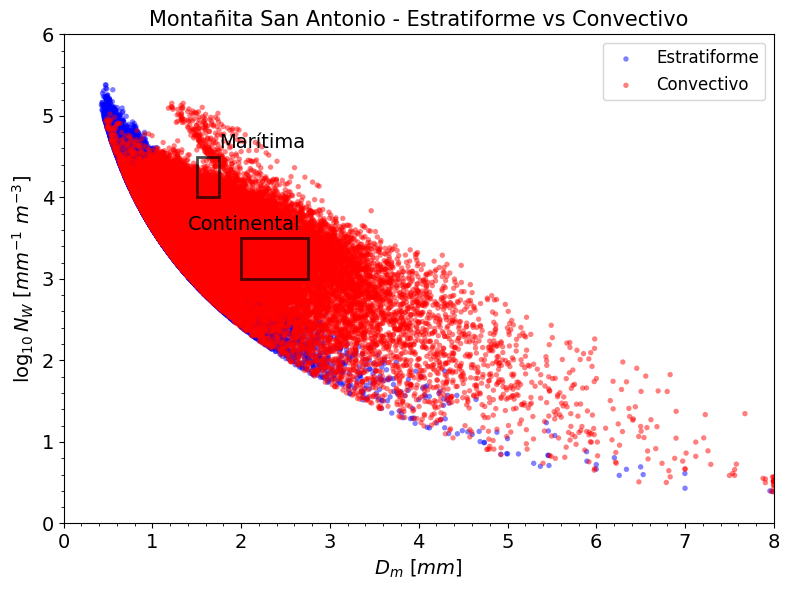

In [60]:
# PROJECT_ROOT = Path.cwd().parent
# DATA_PATH = PROJECT_ROOT / "data"
# FIG_PATH = PROJECT_ROOT / "figures"
# instrument_path = FIG_PATH / "Puerto_Triunfo"
# instrument_path.mkdir(parents=True, exist_ok=True)

# station_name = "77"

# ds_JPC = xr.open_zarr(
#     DATA_PATH / "resultados" / "Zarr" / f"{station_name}_filtrado_plot.zarr"
# )

# =========================================================
# 🔄 Filtro adicional sobre lwc_filt aplicado a todo el dataset
# =========================================================

condicion_invalida_2 = (ds_JPC['lwc_filt'] < 0.001) | (ds_JPC['lwc_filt'] > 13)

ds_JPC = ds_JPC.where(~condicion_invalida_2, drop=False)

# =========================================================
# 📊 Configuración
# =========================================================

std_threshold = 2
window_size = 10  # ventanas de 10 muestras consecutivas

# =========================================================
# 🔄 Clasificación estratiforme/convectivo por ventanas
# =========================================================

r_series = ds_JPC.r_int_filt.to_series()

# Rolling STD sobre ventanas de 10 muestras (centrado)
rolling_std = r_series.rolling(window=window_size, center=True, min_periods=window_size).std()

# Clasificación booleana: True = convectivo
is_convective = rolling_std >= std_threshold

# =========================================================
# 📊 Extraer Dm y log10(Nw)
# =========================================================

dm = ds_JPC.d_m_filt.to_series()
log_nw = np.log10(ds_JPC.n_w_filt.to_series())

# Alinear índices (eliminar NaNs producidos por rolling)
valid = is_convective.notna() & dm.notna() & log_nw.notna()

dm = dm[valid]
log_nw = log_nw[valid]
is_conv = is_convective[valid]

strat_mask = ~is_conv
conv_mask = is_conv

# =========================================================
# 🕸️ Crear figura
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Estratiforme (azul)
ax.scatter(
    dm[strat_mask],
    log_nw[strat_mask],
    c='blue',
    s=15,
    alpha=0.5,
    edgecolors='none',
    label='Estratiforme'
)

# Convectivo (rojo)
ax.scatter(
    dm[conv_mask],
    log_nw[conv_mask],
    c='red',
    s=15,
    alpha=0.5,
    edgecolors='none',
    label='Convectivo'
)

# =========================================================
# 📦 Cajas de referencia
# =========================================================

rect1 = patches.Rectangle(
    (1.5, 4), width=0.25, height=0.5,
    linewidth=2, edgecolor='black', facecolor='none', alpha=0.7
)
rect2 = patches.Rectangle(
    (2, 3), width=0.75, height=0.5,
    linewidth=2, edgecolor='black', facecolor='none', alpha=0.7
)
ax.add_patch(rect1)
ax.add_patch(rect2)

plt.text(1.4, 3.6, 'Continental', fontsize=14, color='black')
plt.text(1.75, 4.6, 'Marítima', fontsize=14, color='black')

# =========================================================
# 🏷️ Etiquetas
# =========================================================

ax.set_xlabel('$D_m\\ [mm]$', fontsize=14)
ax.set_ylabel('$\\log_{10}N_W\\ [mm^{-1}\\ m^{-3}]$', fontsize=14)
ax.set_title(f'{station_name} - Estratiforme vs Convectivo', fontsize=15)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax.set_xlim(0, 8)
ax.set_ylim(0, 6)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

ax.legend(fontsize=12)

plt.tight_layout()

# plt.savefig(
#     instrument_path / f"{station_name}_Dm_Nw_Estrat_Conv.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [50]:
ds_JPC = ds_JPC.dropna(dim="time", subset=["lwc_filt"])

```python
# =========================================================
# 📊 Configuración
# =========================================================

month = 10  # Mes a graficar (1 = Enero)
std_threshold = 2  # Umbral STD(r_int_filt) estratiforme/convectivo

stations = {
    "Torre SIATA": "77_filtrado_plot.zarr",
    # "Parque 3 Aguas": "78_filtrado_plot.zarr",
    # "Santa Rita Guatapé": "139_filtrado_plot.zarr",
    # "Samaná": "159_filtrado_plot.zarr",
    # "La Estrella": "231_filtrado_plot.zarr",
    # "Puerto Triunfo": "257_filtrado_plot.zarr",
    # "Radar de Vientos": "351_filtrado_plot.zarr",
    # "Montañita San Antonio": "425_filtrado_plot.zarr"
}

# Marcadores distintos por estación (8 estaciones -> 8 símbolos)
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

# =========================================================
# 🕸️ Crear figura
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

for (station_name, zarr_file), marker in zip(stations.items(), markers):

    ds = xr.open_zarr(
        DATA_PATH / "resultados" / "Zarr" / zarr_file
    )

    # Filter
    ds = ds.dropna(dim="time", subset=["lwc_filt"])

    # Seleccionar el mes deseado
    ds_month = ds.where(ds.time.dt.month == month, drop=True)

    # =====================================================
    # 🌧️ Clasificación por eventos
    # =====================================================

    start, end = Func.get_events(ds_month)

    # Listas para almacenar todos los datos
    dm_strat = []
    nw_strat = []

    dm_conv = []
    nw_conv = []

    for s, e in zip(start, end):

        # Evento individual
        event = ds_month.sel(time=slice(s, e))

        # STD de la tasa de lluvia del evento
        event_std = event.r_int_filt.std().values

        # Dm y log10(Nw) del evento
        dm_event = event.d_m_filt.to_series().dropna()

        nw_event = (
            np.log10(event.n_w_filt)
            .to_series()
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # Clasificación
        if event_std < std_threshold:

            dm_strat.extend(dm_event.values)
            nw_strat.extend(nw_event.values)

        else:

            dm_conv.extend(dm_event.values)
            nw_conv.extend(nw_event.values)

    # =====================================================
    # 📊 Calcular promedio y STD de Dm y log10(Nw) para cada tipo
    # =====================================================

    dm_series = ds_month.d_m_filt.to_series()
    nw_series = np.log10(ds_month.n_w_filt.to_series())

    rain_types = [
    (dm_strat, nw_strat, 'blue', 'Estratiforme'),
    (dm_conv, nw_conv, 'red', 'Convectivo')
]

for dm_values, nw_values, color, label_suffix in rain_types:

    if len(dm_values) == 0:
        continue

    mean_dm = np.nanmean(dm_values)
    mean_nw = np.nanmean(nw_values)

    std_dm = np.nanstd(dm_values)
    std_nw = np.nanstd(nw_values)

    # Punto medio
    ax.scatter(
        mean_dm,
        mean_nw,
        color=color,
        marker=marker,
        s=80,
        edgecolors='black',
        linewidths=0.8,
        zorder=3,
        label=f"{station_name} - {label_suffix}"
    )

    # Barras de error
    ax.errorbar(
        mean_dm,
        mean_nw,
        xerr=std_dm,
        yerr=std_nw,
        fmt='none',
        ecolor=color,
        elinewidth=1.5,
        capsize=4,
        zorder=2
    )

# =========================================================
# 📦 Cajas de referencia
# =========================================================

rect1 = patches.Rectangle(
    (1.5, 4), width=0.25, height=0.5,
    linewidth=2, edgecolor='red', facecolor='none', alpha=0.7
)
rect2 = patches.Rectangle(
    (2, 3), width=0.75, height=0.5,
    linewidth=2, edgecolor='red', facecolor='none', alpha=0.7
)
ax.add_patch(rect1)
ax.add_patch(rect2)

plt.text(1.4, 3.6, 'Continental', fontsize=14, color='red')
plt.text(1.75, 4.6, 'Marítima', fontsize=14, color='red')

# =========================================================
# 🏷️ Etiquetas
# =========================================================

ax.set_xlabel('$D_m\\ [mm]$', fontsize=14)
ax.set_ylabel('$\\log_{10}N_W\\ [mm^{-1}\\ m^{-3}]$', fontsize=14)
ax.set_title(
    f'Comparación de estaciones - {month_names[month]} '
    f'(Estratiforme vs Convectivo)',
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# ax.set_xlim(0, 8)
# ax.set_ylim(0, 6)

# =========================================================
# 🏷️ Leyenda personalizada
# =========================================================

# Leyenda de colores (tipo de lluvia)
from matplotlib.lines import Line2D

color_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='Estratiforme'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='black', markersize=10, label='Convectivo'),
]

# Leyenda de marcadores (estación)
station_legend = [
    Line2D([0], [0], marker=m, color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=10, label=name)
    for (name, _), m in zip(stations.items(), markers)
]

legend1 = ax.legend(handles=color_legend, loc='upper left',
                     fontsize=12, title="Tipo de lluvia")
ax.add_artist(legend1)

ax.legend(handles=station_legend, loc='upper right',
          fontsize=10, title="Estación")

plt.tight_layout()

# plt.savefig(
#     instrument_path / f"Comparacion_Dm_Nw_{month_names[month]}_Estrat_Conv.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show() ```

execution time = 6.15 minutes